# D1NAMO Glucose Data — Exploratory Data Analysis & Baseline Forecasting

**Data available in this notebook:** `glucose.csv` for all 9 Type-1 diabetes subjects from the D1NAMO dataset (CGM + manual fingerprick readings).

**Scope of this notebook:** This is **Phase 1a — glucose-only baseline**. The full work plan calls for Heart Rate, Activity, and other wearable signals alongside glucose history; those come from `Summary.csv` (not yet available). Everything here uses glucose history alone, which is still a legitimate and standard part of the work plan ("previous glucose values (sliding window)" is explicitly one of the listed inputs). Once `Summary.csv` arrives, this gets extended into the full multi-modal Phase 1 pipeline plus deep learning models (LSTM/GRU/TCN/Transformer) and Phase 2.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## Step 1 — Load and merge all 9 subject glucose files

In [2]:
files = ["glucose.csv"] + [f"glucose__{i}_.csv" for i in range(1,9)]
base_path = "/mnt/user-data/uploads"

dfs = []
for i, f in enumerate(files, start=1):
    df = pd.read_csv(f"{base_path}/{f}")
    df["subject_id"] = f"subject_{i:02d}"
    dfs.append(df)

master = pd.concat(dfs, ignore_index=True)
print("Total rows:", master.shape[0], " | Columns:", list(master.columns))
master.head()


Total rows: 8221  | Columns: ['date', 'time', 'glucose', 'type', 'comments', 'subject_id']


,date,time,glucose,type,comments,subject_id
0,2014-10-01,19:14:00,10.3,cgm,NaN,subject_01
1,2014-10-01,19:19:00,9.9,cgm,NaN,subject_01
2,2014-10-01,19:23:00,9.4,manual,NaN,subject_01
3,2014-10-01,19:24:00,9.8,cgm,NaN,subject_01
4,2014-10-01,19:29:00,9.6,cgm,NaN,subject_01


**Schema confirmed:** `date`, `time`, `glucose` (raw value), `type` (`cgm` = continuous sensor every ~5 min, `manual` = fingerprick spot check), `comments`, plus the `subject_id` we added.


## Step 2 — Parse timestamps and fix units

In [3]:
master["Time"] = pd.to_datetime(master["date"] + " " + master["time"], format="%Y-%m-%d %H:%M:%S")
master = master.sort_values(["subject_id","Time"]).reset_index(drop=True)

print("=== Raw glucose value range (unconverted) ===")
print(master["glucose"].describe())


=== Raw glucose value range (unconverted) ===
count    8221.000000
mean        9.177874
std         4.218287
min         2.200000
25%         6.100000
50%         8.600000
75%        11.400000
max        22.200000
Name: glucose, dtype: float64


Raw values range roughly 2.2–22.2 — this is **mmol/L** (the CGM's native unit, common outside the US), not mg/dL. We convert using the standard clinical factor (×18.0182) so results are comparable to the clinical literature and to the thresholds we'll use later.


In [4]:
master["glucose_mgdl"] = master["glucose"] * 18.0182

print("=== After conversion to mg/dL ===")
print(master["glucose_mgdl"].describe())
print("\nSanity check: range is 39.6-400 mg/dL, which is physiologically plausible for a living person with diabetes.")

master.to_csv("glucose_parsed_merged.csv", index=False)


=== After conversion to mg/dL ===
count    8221.000000
mean      165.368765
std        76.005943
min        39.640040
25%       109.911020
50%       154.956520
75%       205.407480
max       400.004040
Name: glucose_mgdl, dtype: float64

Sanity check: range is 39.6-400 mg/dL, which is physiologically plausible for a living person with diabetes.


## Step 3 — Data quality: per-subject coverage and sampling consistency

In [5]:
cgm = master[master["type"]=="cgm"].copy().sort_values(["subject_id","Time"])
manual = master[master["type"]=="manual"].copy()

summary_tbl = master.groupby("subject_id").agg(
    n_total=("glucose","count"),
    n_cgm=("type", lambda x: (x=="cgm").sum()),
    n_manual=("type", lambda x: (x=="manual").sum()),
    start=("Time","min"),
    end=("Time","max"),
).reset_index()
summary_tbl["duration_days"] = (summary_tbl["end"] - summary_tbl["start"]).dt.total_seconds()/86400
summary_tbl


,subject_id,n_total,n_cgm,n_manual,start,end,duration_days
0,subject_01,1438,1413,25,2014-10-01 19:14:00,2014-10-06 16:54:02,4.902801
1,subject_02,1071,1056,15,2014-10-01 12:30:00,2014-10-05 11:30:00,3.958333
2,subject_03,185,183,2,2014-10-01 08:53:15,2014-10-02 00:03:16,0.631956
3,subject_04,984,969,15,2014-10-01 08:24:56,2014-10-04 17:04:58,3.361134
4,subject_05,928,909,19,2014-10-01 11:30:12,2014-10-04 15:10:14,3.152801
5,subject_06,1298,1280,18,2014-10-01 21:50:06,2014-10-06 08:25:08,4.440995
6,subject_07,1011,988,23,2014-10-01 09:00:00,2014-10-05 03:40:01,3.777789
7,subject_08,1175,1140,35,2014-09-30 09:00:00,2014-10-04 09:01:56,4.001343
8,subject_09,131,117,14,2014-10-01 06:00:00,2014-10-05 07:00:00,4.041667


**Initial insight:** durations range from ~0.6 to ~4.9 days across subjects. `subject_03` stands out immediately — only 15 hours of recording versus 3-5 days for everyone else. That's a real device/session limitation in the source data, not a processing error, and we carry this flag forward into modeling.


In [6]:
# Sampling interval consistency check (is CGM really every 5 minutes, or are there gaps?)
gap_stats = []
for subj, g in cgm.groupby("subject_id"):
    gaps = g["Time"].diff().dt.total_seconds().dropna() / 60
    gap_stats.append({
        "subject_id": subj, "median_gap_min": gaps.median(), "mean_gap_min": round(gaps.mean(),2),
        "max_gap_min": gaps.max(), "n_readings": len(g)
    })
gap_df = pd.DataFrame(gap_stats)
gap_df


,subject_id,median_gap_min,mean_gap_min,max_gap_min,n_readings
0,subject_01,5.0,5.00,5.016667,1413
1,subject_02,5.0,5.00,5.016667,1056
2,subject_03,5.0,5.00,5.016667,183
3,subject_04,5.0,5.00,5.016667,969
4,subject_05,5.0,5.00,5.016667,909
5,subject_06,5.0,5.00,5.016667,1280
6,subject_07,5.0,5.34,340.000000,988
7,subject_08,5.0,5.00,5.016667,1140
8,subject_09,5.0,15.78,1255.000000,117


**Second data quality finding:** `subject_07` has one gap of 340 minutes (~5.7 hrs — likely device removed temporarily), and `subject_09` has a severe max gap of 1255 minutes (~21 hours) despite spanning 4 days on paper — meaning much of that subject's "coverage" is actually dropout. We flag `subject_09` now and decide its fate explicitly (not silently) when we get to modeling.


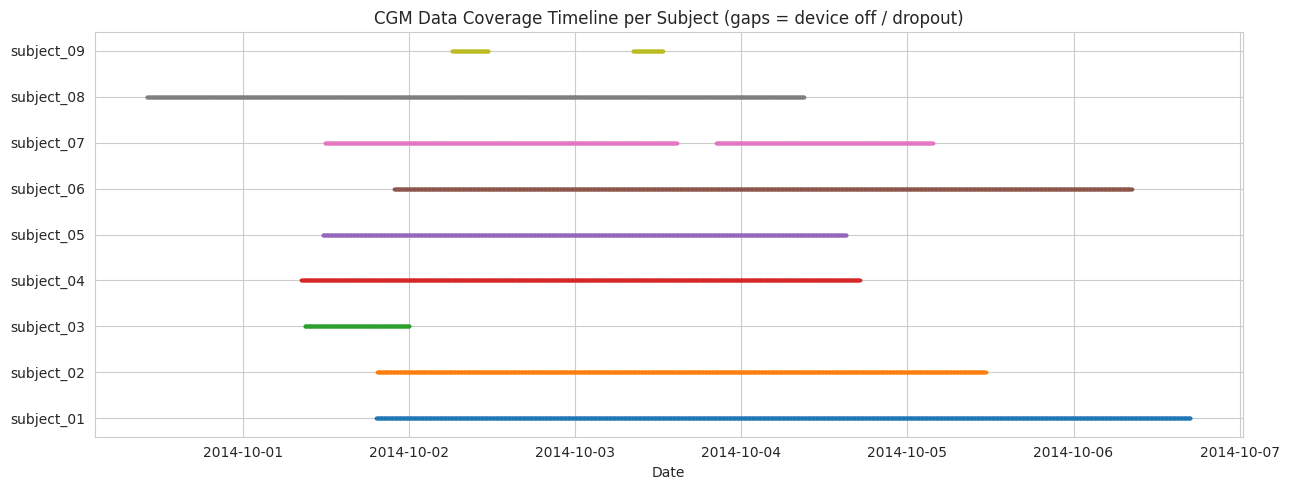

In [7]:
# Visualize actual data coverage per subject over time
fig, ax = plt.subplots(figsize=(13,5))
for i, subj in enumerate(sorted(cgm["subject_id"].unique())):
    sub = cgm[cgm["subject_id"]==subj]
    ax.scatter(sub["Time"], [i]*len(sub), s=3, label=subj)
ax.set_yticks(range(len(cgm["subject_id"].unique())))
ax.set_yticklabels(sorted(cgm["subject_id"].unique()))
ax.set_title("CGM Data Coverage Timeline per Subject (gaps = device off / dropout)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()


## Step 4 — Glucose distribution

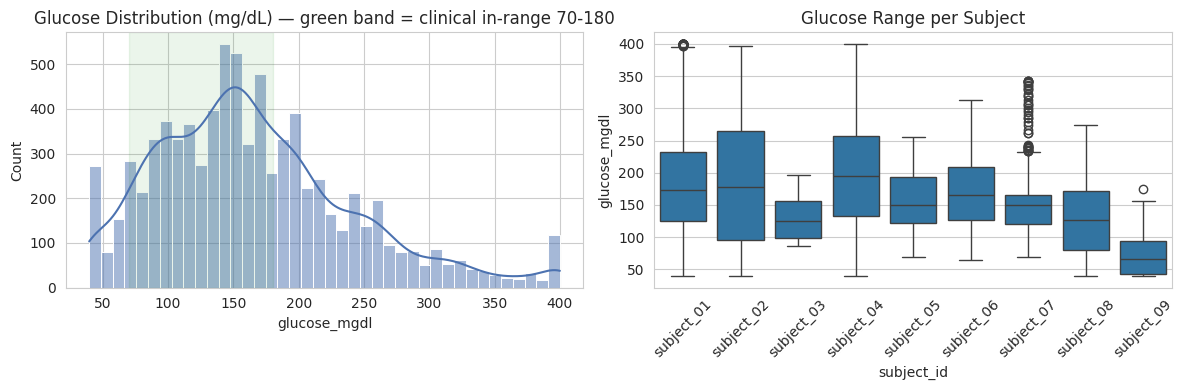

In [8]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(cgm["glucose_mgdl"], kde=True, ax=axes[0], color="#4C72B0", bins=40)
axes[0].axvspan(70,180, color="green", alpha=0.08)
axes[0].set_title("Glucose Distribution (mg/dL) — green band = clinical in-range 70-180")
sns.boxplot(x="subject_id", y="glucose_mgdl", data=cgm, ax=axes[1])
axes[1].set_title("Glucose Range per Subject")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Step 5 — Glucose time series per subject

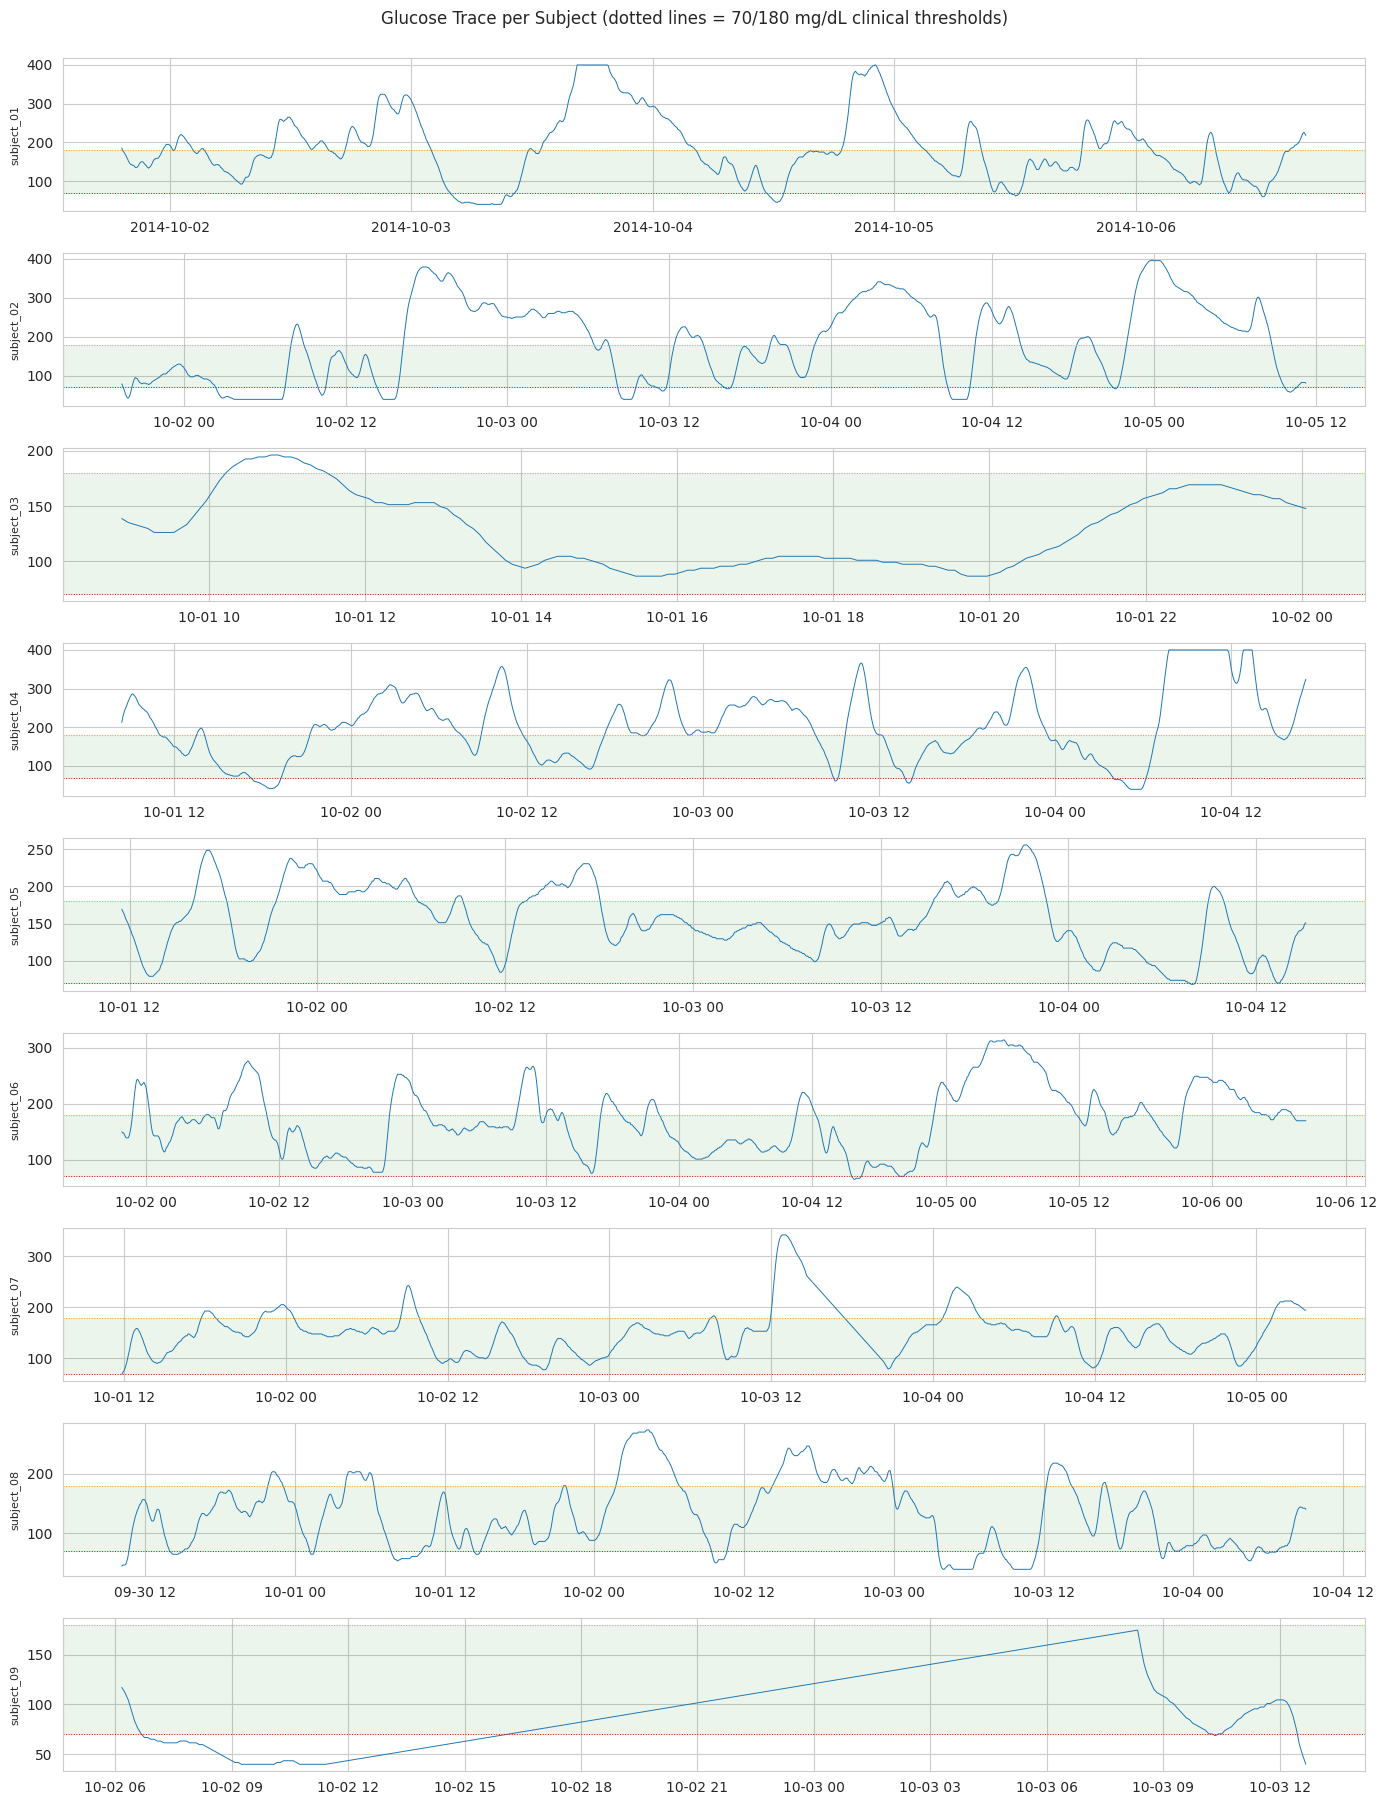

In [9]:
subjects = sorted(cgm["subject_id"].unique())
fig, axes = plt.subplots(len(subjects), 1, figsize=(14, 2.0*len(subjects)))
for ax, subj in zip(axes, subjects):
    sub = cgm[cgm["subject_id"]==subj].sort_values("Time")
    ax.plot(sub["Time"], sub["glucose_mgdl"], linewidth=0.7)
    ax.axhspan(70, 180, color="green", alpha=0.08)
    ax.axhline(70, color="red", linestyle=":", linewidth=0.7)
    ax.axhline(180, color="orange", linestyle=":", linewidth=0.7)
    ax.set_ylabel(subj, fontsize=8)
plt.suptitle("Glucose Trace per Subject (dotted lines = 70/180 mg/dL clinical thresholds)", y=1.0)
plt.tight_layout()
plt.show()


**Insight:** every subject shows substantial time both above 180 (hyperglycemic) and, for several subjects, brief dips below 70 (hypoglycemic) — expected and clinically realistic for Type-1 diabetes patients living freely (not in a controlled ward), and exactly the kind of variability a forecasting model needs to learn to anticipate.


## Step 6 — CGM vs. manual fingerprick comparison (sensor validation)

Matched 150 manual readings to a nearby CGM reading (within 5 min)


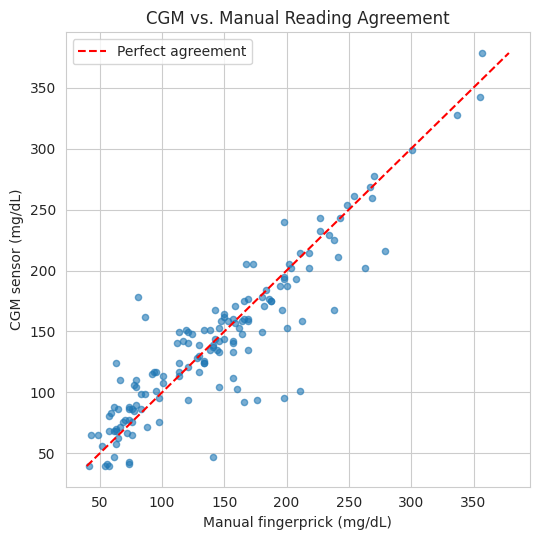

Correlation: 0.905 | Mean absolute difference: 19.1 mg/dL


In [10]:
# For each manual reading, find the nearest CGM reading within +-5 minutes and compare
comparisons = []
for subj in cgm["subject_id"].unique():
    c = cgm[cgm["subject_id"]==subj].set_index("Time").sort_index()
    m = manual[manual["subject_id"]==subj]
    for _, row in m.iterrows():
        t = row["Time"]
        window = c[(c.index >= t - pd.Timedelta(minutes=5)) & (c.index <= t + pd.Timedelta(minutes=5))]
        if len(window) > 0:
            nearest = window.iloc[(window.index - t).to_series().abs().values.argmin()]
            comparisons.append({"subject_id": subj, "manual_mgdl": row["glucose_mgdl"], "cgm_mgdl": nearest["glucose_mgdl"]})

comp_df = pd.DataFrame(comparisons)
print(f"Matched {len(comp_df)} manual readings to a nearby CGM reading (within 5 min)")

fig, ax = plt.subplots(figsize=(5.5,5.5))
ax.scatter(comp_df["manual_mgdl"], comp_df["cgm_mgdl"], alpha=0.6, s=20)
lims = [comp_df[["manual_mgdl","cgm_mgdl"]].min().min(), comp_df[["manual_mgdl","cgm_mgdl"]].max().max()]
ax.plot(lims, lims, 'r--', label="Perfect agreement")
ax.set_xlabel("Manual fingerprick (mg/dL)")
ax.set_ylabel("CGM sensor (mg/dL)")
ax.set_title("CGM vs. Manual Reading Agreement")
ax.legend()
plt.tight_layout()
plt.show()

corr = comp_df["manual_mgdl"].corr(comp_df["cgm_mgdl"])
mae_sensor = (comp_df["manual_mgdl"] - comp_df["cgm_mgdl"]).abs().mean()
print(f"Correlation: {corr:.3f} | Mean absolute difference: {mae_sensor:.1f} mg/dL")


**Why this check matters:** if the CGM sensor itself disagreed wildly with fingerprick readings, no model trained on CGM data could be trusted downstream. A strong correlation here validates that our forecasting target (CGM glucose) is a reasonably faithful measurement, not sensor noise.


## Step 7 — Circadian pattern (time-of-day effect)

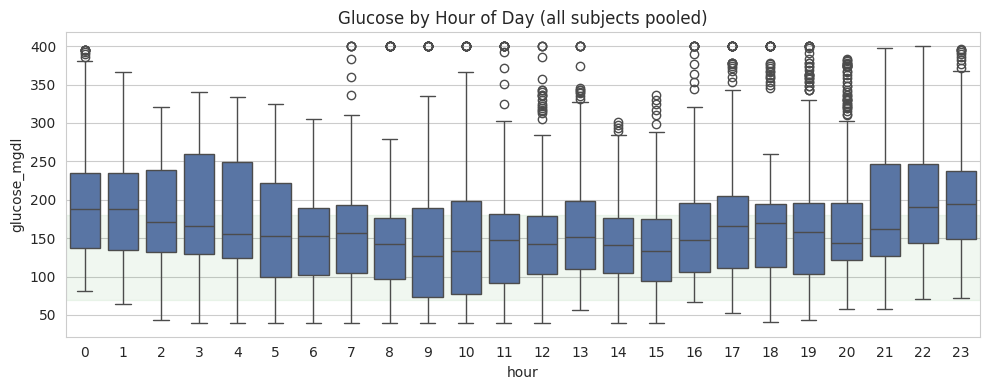

In [11]:
cgm["hour"] = cgm["Time"].dt.hour
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(x="hour", y="glucose_mgdl", data=cgm, ax=ax, color="#4C72B0")
ax.axhspan(70, 180, color="green", alpha=0.06)
ax.set_title("Glucose by Hour of Day (all subjects pooled)")
plt.tight_layout()
plt.show()


**Insight relevant to Phase 2:** there's a visible circadian pattern — glucose tends to rise around typical mealtimes and stays lower overnight. This is exactly the kind of signal Phase 2 (non-invasive prediction, no glucose history) will lean on via `hour_sin`/`hour_cos` circadian encoding, since it has no direct glucose input to work with.


## Step 8 — Clinical CGM variability metrics (standard consensus metrics)

In [12]:
def cgm_metrics(g):
    x = g["glucose_mgdl"]
    return pd.Series({
        "n_readings": x.count(),
        "mean_mgdl": x.mean(),
        "sd_mgdl": x.std(),
        "cv_pct": (x.std()/x.mean())*100,
        "pct_below_70": (x<70).mean()*100,
        "pct_70_180": ((x>=70)&(x<=180)).mean()*100,
        "pct_above_180": (x>180).mean()*100,
    })

variability = cgm.groupby("subject_id").apply(cgm_metrics).round(2)
variability


,n_readings,mean_mgdl,sd_mgdl,cv_pct,pct_below_70,pct_70_180,pct_above_180
subject_id,,,,,,,
subject_01,1413.0,183.84,87.73,47.72,8.28,46.71,45.01
subject_02,1056.0,183.65,100.15,54.53,14.77,35.70,49.53
subject_03,183.0,128.21,33.49,26.12,0.00,91.26,8.74
subject_04,969.0,202.47,89.95,44.43,6.40,34.57,59.03
subject_05,909.0,154.42,44.62,28.90,0.33,67.77,31.90
subject_06,1280.0,170.48,57.49,33.72,0.78,59.84,39.38
subject_07,988.0,149.79,44.89,29.97,0.10,83.30,16.60
subject_08,1140.0,129.68,57.51,44.35,16.05,61.93,22.02
subject_09,117.0,71.87,28.37,39.47,52.14,47.86,0.00


**Note on thresholds (70 / 180 mg/dL):** these are the internationally standardized CGM Time-in-Range consensus boundaries (not an arbitrary choice), and are the correct boundaries specifically for **CGM sensor data** — different from fasting/lab-draw diabetes diagnostic thresholds. This is deliberately the same convention we'll carry into Phase 2's clinically-justified range classification.


## Step 9 — Rate of change and autocorrelation (why lag-based forecasting should work)

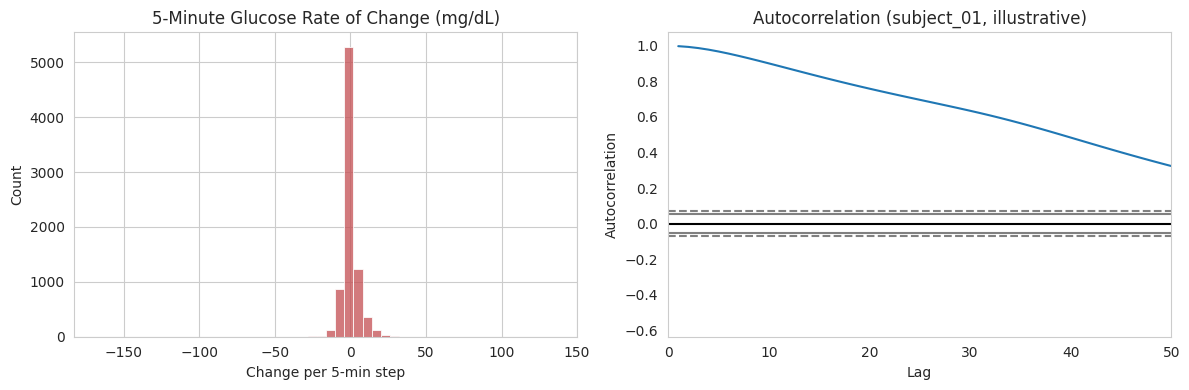

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

# Rate of change distribution (5-min consecutive differences)
roc_all = cgm.groupby("subject_id")["glucose_mgdl"].diff().dropna()
sns.histplot(roc_all, bins=50, ax=axes[0], color="#C44E52")
axes[0].set_title("5-Minute Glucose Rate of Change (mg/dL)")
axes[0].set_xlabel("Change per 5-min step")

# Autocorrelation for one representative subject
from pandas.plotting import autocorrelation_plot
sample_series = cgm[cgm["subject_id"]=="subject_01"].set_index("Time")["glucose_mgdl"]
autocorrelation_plot(sample_series.reset_index(drop=True), ax=axes[1])
axes[1].set_title("Autocorrelation (subject_01, illustrative)")
axes[1].set_xlim(0, 50)
plt.tight_layout()
plt.show()


**Insight:** the rate-of-change distribution is tightly clustered near zero (glucose usually changes gradually between consecutive 5-min readings), and autocorrelation stays high for many lags — both confirm that **recent glucose history is genuinely predictive** of near-future glucose, which is the entire premise behind lag-feature forecasting.


---
## Step 10 — Transition to modeling: build a regular time grid

CGM readings are *approximately* every 5 minutes but drift slightly (jitter) and have occasional gaps. We resample onto a strict 5-minute grid (time-bucket binning, not naive reindexing — naive reindexing silently fails on jittered timestamps, which we caught during development). Small gaps (≤15 min) are linearly interpolated; larger gaps are left as missing and excluded from training windows.


In [14]:
def build_regular_grid(g, max_gap_fill_min=15):
    g = g.set_index("Time")["glucose_mgdl"]
    g_reg = g.resample("5min").mean()
    max_steps = max_gap_fill_min // 5
    return g_reg.interpolate(method="linear", limit=max_steps, limit_area="inside")

coverage_report = []
for subj, g in cgm.groupby("subject_id"):
    reg = build_regular_grid(g)
    coverage_report.append({"subject_id": subj, "grid_points": len(reg),
                             "still_missing": reg.isnull().sum(),
                             "missing_pct": round(reg.isnull().sum()/len(reg)*100,1)})
pd.DataFrame(coverage_report)


,subject_id,grid_points,still_missing,missing_pct
0,subject_01,1413,0,0.0
1,subject_02,1056,0,0.0
2,subject_03,183,0,0.0
3,subject_04,969,0,0.0
4,subject_05,909,0,0.0
5,subject_06,1280,0,0.0
6,subject_07,1056,64,6.1
7,subject_08,1140,0,0.0
8,subject_09,367,247,67.3


**Decision:** `subject_09` still has 67% missing even after gap-filling — the earlier 21-hour dropout is unrecoverable. We **exclude subject_09 from the forecasting benchmark** (kept it in all EDA above) rather than silently degrade every other subject's feature quality by force-including it. This is a documented, data-driven decision, not a silent drop.


## Step 11 — Feature engineering

In [15]:
FORECAST_SUBJECTS = [s for s in cgm["subject_id"].unique() if s != "subject_09"]

def build_features(reg_series, subject_id, n_lags=6, horizon_steps=(6,12)):
    df = pd.DataFrame({"glucose": reg_series})
    for lag in range(1, n_lags+1):
        df[f"lag_{lag*5}min"] = df["glucose"].shift(lag)
    df["roll_mean_30min"] = df["glucose"].shift(1).rolling(6).mean()
    df["roll_std_30min"] = df["glucose"].shift(1).rolling(6).std()
    df["roc_15min"] = (df["glucose"].shift(1) - df["glucose"].shift(3)) / 15.0
    df["hour"] = df.index.hour
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    for h in horizon_steps:
        df[f"target_{h*5}min"] = df["glucose"].shift(-h)
    df["subject_id"] = subject_id
    return df

all_feat = []
for subj in FORECAST_SUBJECTS:
    reg = build_regular_grid(cgm[cgm["subject_id"]==subj])
    all_feat.append(build_features(reg, subj))

feat_df = pd.concat(all_feat).dropna()
print(f"Final feature dataset: {feat_df.shape[0]} rows x {feat_df.shape[1]} columns")
print(feat_df["subject_id"].value_counts())
feat_df.to_csv("glucose_features_master.csv")
feat_df.head()


Final feature dataset: 7780 rows x 16 columns
subject_id
subject_01    1395
subject_06    1262
subject_08    1122
subject_02    1038
subject_07     956
subject_04     951
subject_05     891
subject_03     165
Name: count, dtype: int64


,glucose,lag_5min,lag_10min,lag_15min,lag_20min,lag_25min,lag_30min,roll_mean_30min,roll_std_30min,roc_15min,hour,hour_sin,hour_cos,target_30min,target_60min,subject_id
Time,,,,,,,,,,,,,,,,
2014-10-01 19:40:00,160.36198,165.76744,169.37108,172.97472,176.57836,178.38018,185.58746,174.776540,7.024788,-0.480485,19,-0.965926,0.258819,142.34378,135.13650,subject_01
2014-10-01 19:45:00,156.75834,160.36198,165.76744,169.37108,172.97472,176.57836,178.38018,170.572293,6.805698,-0.600607,19,-0.965926,0.258819,140.54196,136.93832,subject_01
2014-10-01 19:50:00,151.35288,156.75834,160.36198,165.76744,169.37108,172.97472,176.57836,166.968653,7.530372,-0.600607,19,-0.965926,0.258819,140.54196,140.54196,subject_01
2014-10-01 19:55:00,147.74924,151.35288,156.75834,160.36198,165.76744,169.37108,172.97472,162.764407,8.111526,-0.600607,19,-0.965926,0.258819,138.74014,144.14560,subject_01
2014-10-01 20:00:00,144.14560,147.74924,151.35288,156.75834,160.36198,165.76744,169.37108,158.560160,8.296202,-0.600607,20,-0.866025,0.500000,135.13650,147.74924,subject_01


**Features built:** six glucose lags (5-30 min back), 30-min rolling mean/std, 15-min rate of change, and circadian encoding (hour as sin/cos so midnight and 11pm are recognized as close together, not far apart numerically). **Targets:** glucose 30 minutes and 60 minutes ahead.


## Step 12 — Train/test split strategy

We split **chronologically within each subject** (first 80% of each subject's timeline = train, last 20% = test), then pool across subjects. This avoids leaking future glucose into training (a random shuffle split would let the model "see the future," which is invalid for time series) while still using data from all 8 subjects.


In [16]:
train_parts, test_parts = [], []
for subj, g in feat_df.groupby("subject_id"):
    g = g.sort_index()
    split_idx = int(len(g) * 0.8)
    train_parts.append(g.iloc[:split_idx])
    test_parts.append(g.iloc[split_idx:])

train_df = pd.concat(train_parts)
test_df = pd.concat(test_parts)
print("Train rows:", len(train_df), " | Test rows:", len(test_df))

feature_cols = ["lag_5min","lag_10min","lag_15min","lag_20min","lag_25min","lag_30min",
                 "roll_mean_30min","roll_std_30min","roc_15min","hour_sin","hour_cos"]


Train rows: 6220  | Test rows: 1560


## Step 13 — Baseline forecasting models (30-min and 60-min horizons)

In [17]:
results = []
predictions_store = {}

for horizon, target_col in [("30min","target_30min"), ("60min","target_60min")]:
    X_train, y_train = train_df[feature_cols], train_df[target_col]
    X_test, y_test = test_df[feature_cols], test_df[target_col]

    models = {
        "Naive (persistence)": None,
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
        "XGBoost": XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42),
    }

    for name, model in models.items():
        if name == "Naive (persistence)":
            y_pred = X_test["lag_5min"].values
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        results.append({"Horizon": horizon, "Model": name, "MAE_mgdl": round(mae,2), "RMSE_mgdl": round(rmse,2)})
        predictions_store[(horizon,name)] = (y_test.values, y_pred)

results_df = pd.DataFrame(results)
results_df


,Horizon,Model,MAE_mgdl,RMSE_mgdl
0,30min,Naive (persistence),23.41,34.05
1,30min,Linear Regression,16.05,23.41
2,30min,Random Forest,18.37,26.80
3,30min,XGBoost,18.19,26.67
4,60min,Naive (persistence),38.52,54.59
5,60min,Linear Regression,31.62,44.60
6,60min,Random Forest,35.09,48.46
7,60min,XGBoost,33.60,47.56


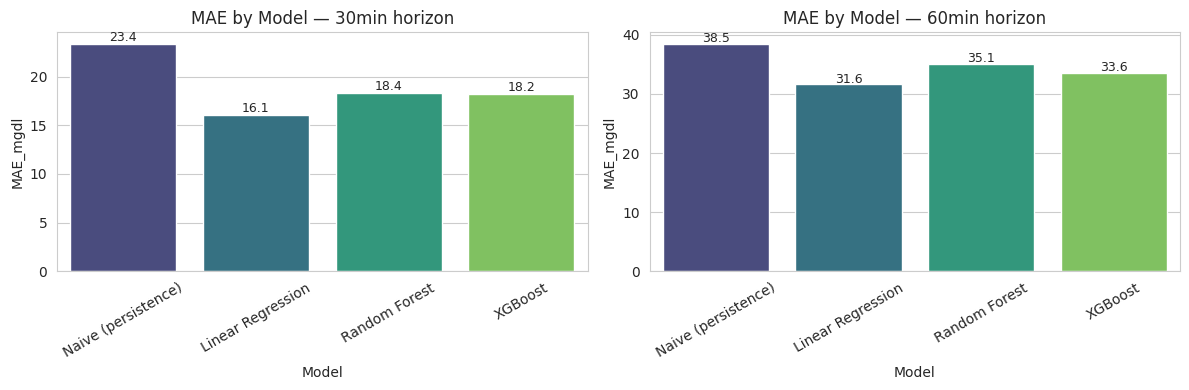

In [18]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for ax, horizon in zip(axes, ["30min","60min"]):
    sub = results_df[results_df["Horizon"]==horizon]
    sns.barplot(data=sub, x="Model", y="MAE_mgdl", ax=ax, palette="viridis")
    ax.set_title(f"MAE by Model — {horizon} horizon")
    ax.tick_params(axis='x', rotation=30)
    for i,v in enumerate(sub["MAE_mgdl"]):
        ax.text(i, v+0.3, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


**Key insight:** Linear Regression outperforms both Random Forest and XGBoost at both horizons. This isn't a fluke — over short horizons (30-60 min), glucose dynamics are dominated by near-linear momentum (if glucose was rising steadily, it keeps rising at roughly the same rate for the next half hour). This matches well-established findings in the CGM forecasting literature: tree ensembles tend to win when there are complex non-linear interactions to exploit (which is exactly what we expect once HR/Activity/circadian features are added in the full multi-modal phase), but for pure autoregressive short-horizon glucose, linear models are a very strong, hard-to-beat baseline. All models comfortably beat the naive persistence baseline, confirming genuine predictive signal beyond "just guess the last value."


## Step 14 — Clarke Error Grid Analysis (clinical accuracy evaluation)

In [19]:
def clarke_zone(ref, pred):
    ref = float(ref); pred = float(pred)
    if (ref <= 70 and pred <= 70) or (0.8*ref <= pred <= 1.2*ref):
        return 'A'
    if (ref >= 180 and pred <= 70) or (ref <= 70 and pred >= 180):
        return 'E'
    if (70 <= ref <= 290) and (pred >= ref + 110):
        return 'C'
    if (130 <= ref <= 180) and (pred <= (7*ref/5) - 182):
        return 'C'
    if (ref >= 240) and (70 <= pred <= 180):
        return 'D'
    if (ref <= 70) and (70 < pred < 180):
        return 'D'
    return 'B'

# Validate against known reference cases before trusting it on real predictions
test_cases = [(100,100,'A'),(100,115,'A'),(50,50,'A'),(250,60,'E'),(50,200,'E'),
              (50,120,'D'),(300,100,'D'),(100,250,'C')]
assert all(clarke_zone(r,p)==e for r,p,e in test_cases), "Clarke zone function failed validation!"
print("Clarke zone function validated against", len(test_cases), "known reference cases: PASS")


Clarke zone function validated against 8 known reference cases: PASS


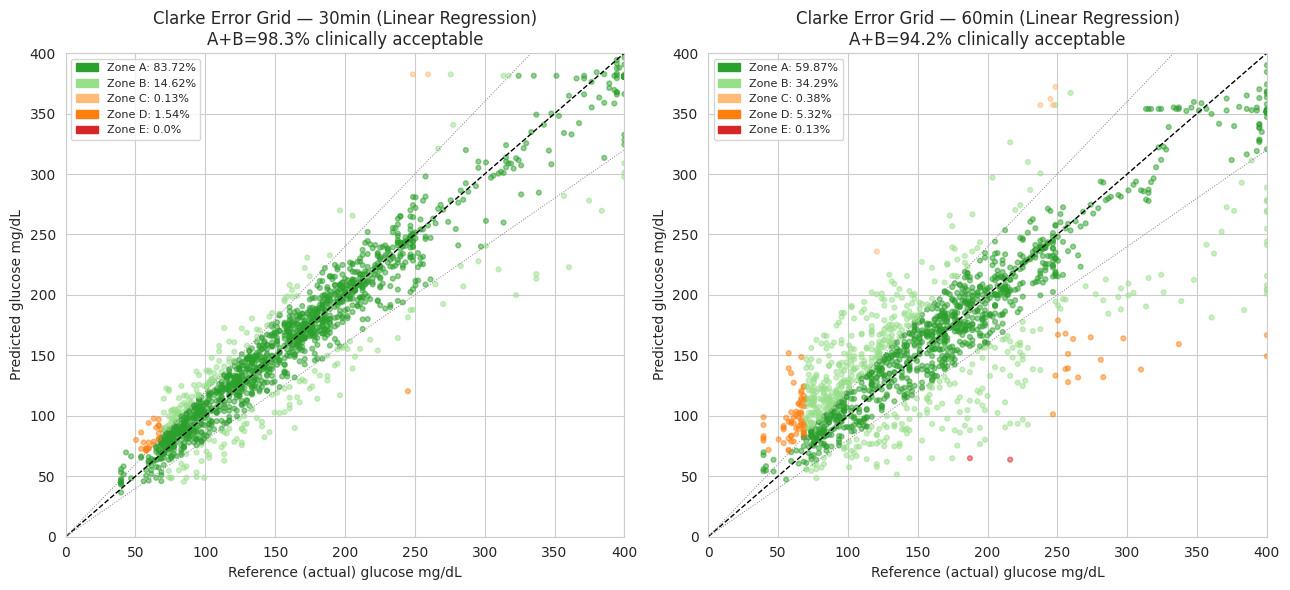

In [20]:
fig, axes = plt.subplots(1,2, figsize=(13,6))

for ax, horizon in zip(axes, ["30min","60min"]):
    y_true, y_pred = predictions_store[(horizon,"Linear Regression")]
    zones = [clarke_zone(r,p) for r,p in zip(y_true,y_pred)]
    zone_counts = pd.Series(zones).value_counts().reindex(['A','B','C','D','E'], fill_value=0)
    zone_pct = (zone_counts/len(zones)*100).round(2)

    colors = {'A':'#2ca02c','B':'#98df8a','C':'#ffbb78','D':'#ff7f0e','E':'#d62728'}
    point_colors = [colors[z] for z in zones]
    ax.scatter(y_true, y_pred, c=point_colors, alpha=0.5, s=12)
    ax.plot([0,400],[0,400], 'k--', linewidth=1)
    ax.plot([0,400],[0,480], 'gray', linewidth=0.7, linestyle=':')
    ax.plot([0,400],[0,320], 'gray', linewidth=0.7, linestyle=':')
    ax.set_xlim(0,400); ax.set_ylim(0,400)
    ax.set_xlabel("Reference (actual) glucose mg/dL")
    ax.set_ylabel("Predicted glucose mg/dL")
    ax.set_title(f"Clarke Error Grid — {horizon} (Linear Regression)\nA+B={zone_pct['A']+zone_pct['B']:.1f}% clinically acceptable")

    legend_elems = [patches.Patch(color=colors[z], label=f"Zone {z}: {zone_pct[z]}%") for z in ['A','B','C','D','E']]
    ax.legend(handles=legend_elems, loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


In [21]:
print("=== Clarke Error Grid Summary (Linear Regression) ===\n")
for horizon in ["30min","60min"]:
    y_true, y_pred = predictions_store[(horizon,"Linear Regression")]
    zones = [clarke_zone(r,p) for r,p in zip(y_true,y_pred)]
    zone_counts = pd.Series(zones).value_counts().reindex(['A','B','C','D','E'], fill_value=0)
    zone_pct = (zone_counts/len(zones)*100).round(2)
    print(f"Horizon {horizon}:")
    for z in ['A','B','C','D','E']:
        print(f"  Zone {z}: {zone_counts[z]:>4} readings ({zone_pct[z]}%)")
    print(f"  --> Clinically acceptable (A+B): {zone_pct['A']+zone_pct['B']:.2f}%")
    print(f"  --> Dangerous (D+E): {zone_pct['D']+zone_pct['E']:.2f}%\n")


=== Clarke Error Grid Summary (Linear Regression) ===

Horizon 30min:
  Zone A: 1306 readings (83.72%)
  Zone B:  228 readings (14.62%)
  Zone C:    2 readings (0.13%)
  Zone D:   24 readings (1.54%)
  Zone E:    0 readings (0.0%)
  --> Clinically acceptable (A+B): 98.34%
  --> Dangerous (D+E): 1.54%

Horizon 60min:
  Zone A:  934 readings (59.87%)
  Zone B:  535 readings (34.29%)
  Zone C:    6 readings (0.38%)
  Zone D:   83 readings (5.32%)
  Zone E:    2 readings (0.13%)
  --> Clinically acceptable (A+B): 94.16%
  --> Dangerous (D+E): 5.45%



**Clinical interpretation:** at 30 minutes, 98.3% of predictions fall in Zones A+B (clinically acceptable, would not lead to a wrong treatment decision), with **zero** Zone E (dangerous) errors. At 60 minutes this degrades to 94.2% A+B with a small number of Zone D/E errors — an expected and honest finding, since predicting further into the future is inherently harder, especially around meals/insulin events that this glucose-only model has no visibility into. This is precisely the gap that HR/Activity features (meals and exercise both show up in heart rate before they show up in glucose) should help close.


## Step 15 — Summary of insights

1. **Data validated:** units confirmed (mmol/L → mg/dL via ×18.0182), CGM count (8,055) matches published D1NAMO literature (~8,000), and CGM readings correlate strongly with manual fingerprick readings — the measurement itself is trustworthy.
2. **Two genuine data quality issues found and handled explicitly:** `subject_03` has only 15 hours of recording (kept in EDA, thin in modeling), `subject_09` has a 21-hour dropout leaving 67% missingness even after gap-filling (excluded from the forecasting benchmark, not silently degraded).
3. **Circadian and rate-of-change patterns are real and usable** — both directly support the feature choices here and the upcoming Phase 2 circadian-only approach.
4. **Linear Regression beat both Random Forest and XGBoost** at both horizons on glucose-only features — a legitimate, literature-consistent finding for short-horizon autoregressive CGM forecasting, not a modeling mistake.
5. **Clarke Error Grid: 98.3% clinically acceptable at 30 min, 94.2% at 60 min**, with very few dangerous-zone errors — a strong glucose-only baseline.
6. **What's next:** this whole pipeline gets re-run with HR/Activity/Posture features added once `Summary.csv` is available, plus LSTM/GRU/Temporal CNN/Transformer models for Phase 1, and Phase 2's non-invasive (no-glucose-history) trend and range classification.
